# Insurance Cost Prediction — Exploratory Data Analysis

We explore the **medical insurance charges** dataset (from Brett Lantz's *ML with R* book) to find which demographic and lifestyle features drive an individual's annual insurance bill.

**Dataset**: 1,338 records with 6 input features (`age`, `sex`, `bmi`, `children`, `smoker`, `region`) and the regression target `charges` (US dollars per year).

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

## 2. Load Data

In [2]:
df = pd.read_csv("data/insurance.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.describe(include='all').round(2)

,age,sex,bmi,children,smoker,region,charges
count,1338.00,1338,1338.00,1338.00,1338,1338,1338.00
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.21,NaN,30.66,1.09,NaN,NaN,13270.42
std,14.05,NaN,6.10,1.21,NaN,NaN,12110.01
min,18.00,NaN,15.96,0.00,NaN,NaN,1121.87
25%,27.00,NaN,26.30,0.00,NaN,NaN,4740.29
50%,39.00,NaN,30.40,1.00,NaN,NaN,9382.03
75%,51.00,NaN,34.69,2.00,NaN,NaN,16639.91


In [5]:
print(f"Duplicate rows : {df.duplicated().sum()}")
print(f"Missing values : {df.isnull().sum().sum()}")

Duplicate rows : 1
Missing values : 0


## 4. Target Variable Distribution

`charges` is heavily right-skewed — typical for spending data. We'll keep that in mind for modeling.

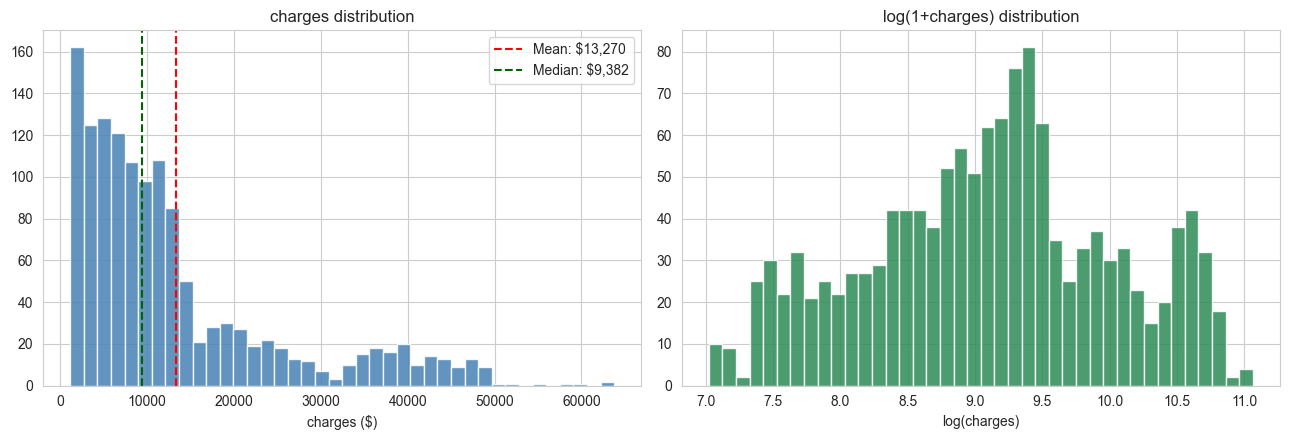

Skewness of charges     : 1.52
Skewness of log(charges): -0.09


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df["charges"], bins=40, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(df["charges"].mean(), color="red", linestyle="--",
                label=f"Mean: ${df['charges'].mean():,.0f}")
axes[0].axvline(df["charges"].median(), color="darkgreen", linestyle="--",
                label=f"Median: ${df['charges'].median():,.0f}")
axes[0].set_title("charges distribution"); axes[0].set_xlabel("charges ($)")
axes[0].legend()

axes[1].hist(np.log1p(df["charges"]), bins=40, color="seagreen", edgecolor="white", alpha=0.85)
axes[1].set_title("log(1+charges) distribution"); axes[1].set_xlabel("log(charges)")
plt.tight_layout(); plt.show()
print(f"Skewness of charges     : {df['charges'].skew():.2f}")
print(f"Skewness of log(charges): {np.log1p(df['charges']).skew():.2f}")

## 5. Univariate — Numeric Features

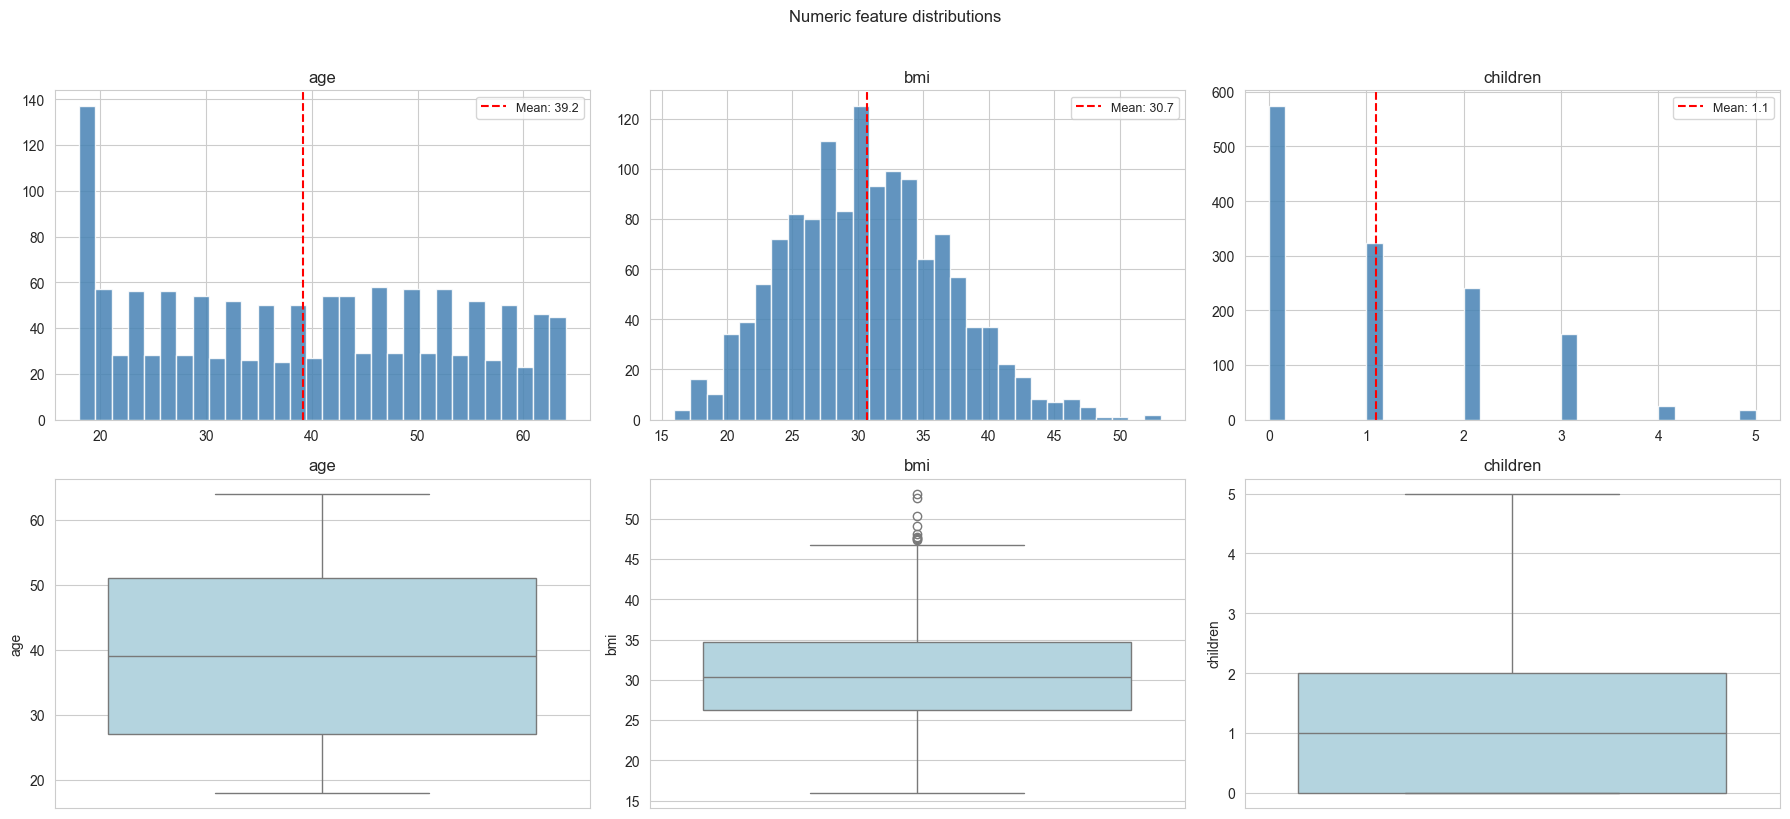

In [7]:
num_features = ["age", "bmi", "children"]
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for i, col in enumerate(num_features):
    df[col].hist(bins=30, color="steelblue", edgecolor="white", alpha=0.85, ax=axes[0,i])
    axes[0,i].axvline(df[col].mean(), color="red", linestyle="--",
                      label=f"Mean: {df[col].mean():.1f}")
    axes[0,i].set_title(col); axes[0,i].legend(fontsize=9)
    sns.boxplot(y=df[col], ax=axes[1,i], color="lightblue")
    axes[1,i].set_title(col)
plt.suptitle("Numeric feature distributions", y=1.02)
plt.tight_layout(); plt.show()

## 6. Univariate — Categorical Features

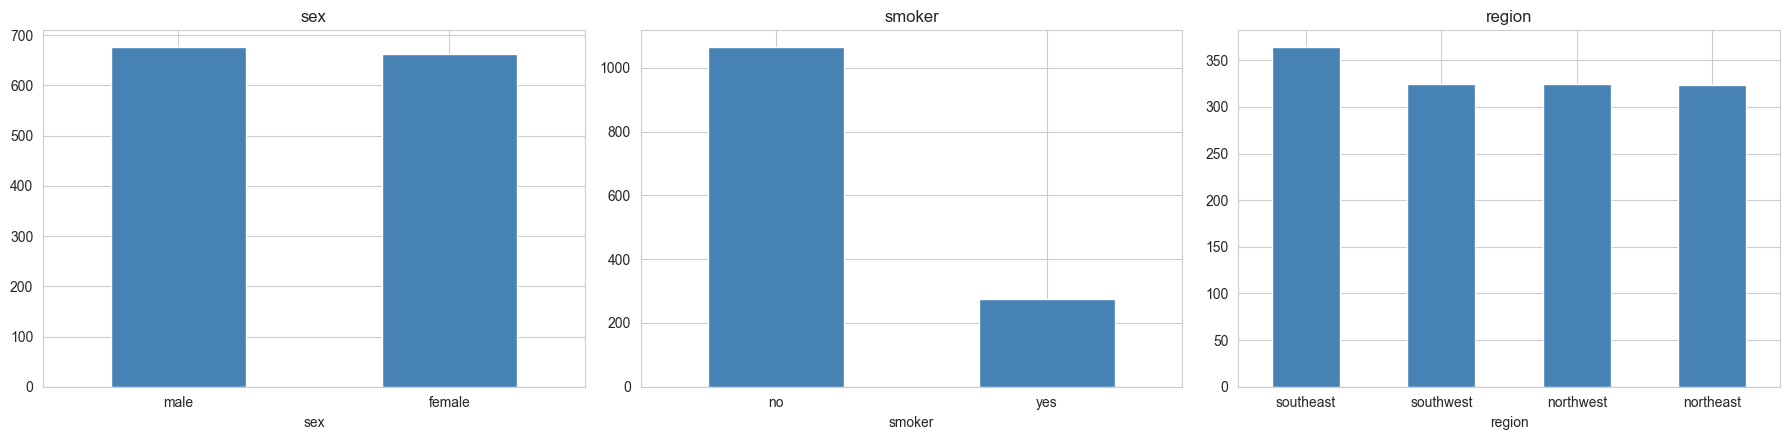

In [8]:
cat_features = ["sex", "smoker", "region"]
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for i, col in enumerate(cat_features):
    df[col].value_counts().plot(kind="bar", color="steelblue", ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## 7. Bivariate — Numeric Features vs Charges

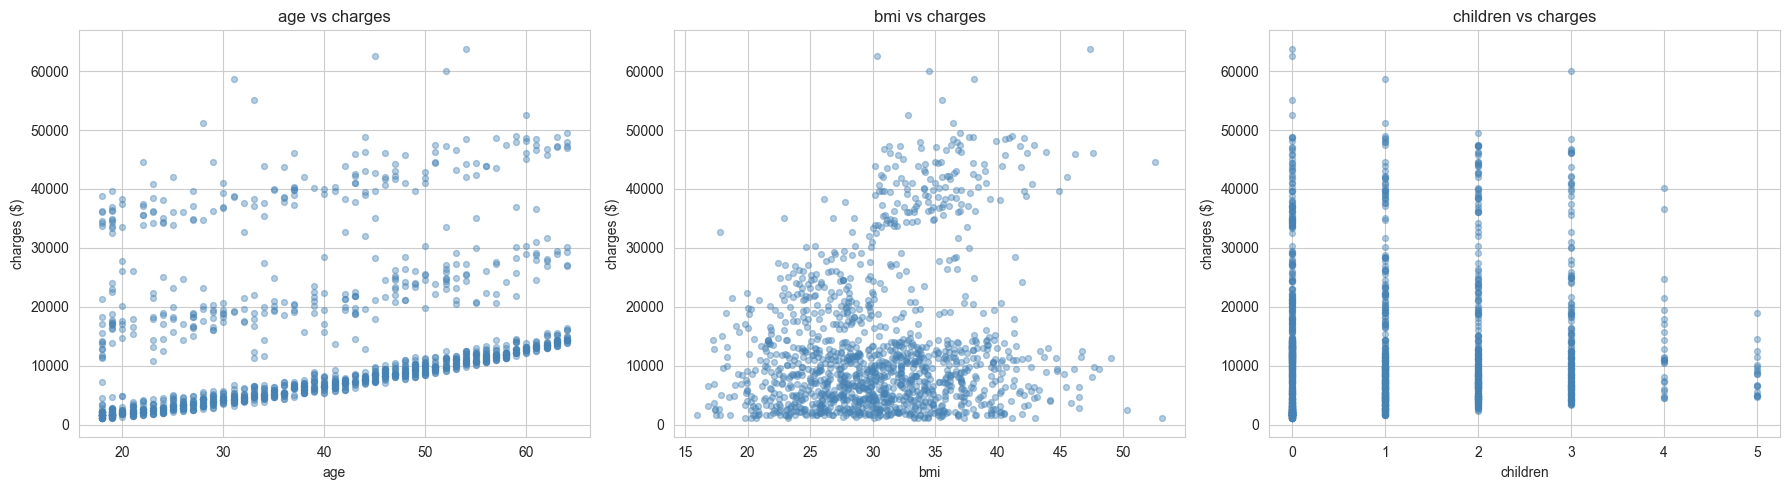

Pearson correlations with charges:
age         0.299
bmi         0.198
children    0.068
Name: charges, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_features):
    axes[i].scatter(df[col], df["charges"], alpha=0.4, color="steelblue", s=18)
    axes[i].set_xlabel(col); axes[i].set_ylabel("charges ($)")
    axes[i].set_title(f"{col} vs charges")
plt.tight_layout(); plt.show()
print("Pearson correlations with charges:")
print(df[num_features + ["charges"]].corr()["charges"].drop("charges").round(3))

## 8. Bivariate — Categorical Features vs Charges

/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_41346/4007458044.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y="charges", data=df, palette="Set2", ax=axes[i])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_41346/4007458044.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y="charges", data=df, palette="Set2", ax=axes[i])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_41346/4007458044.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y="charges", data=df, palette="Set2", ax=a

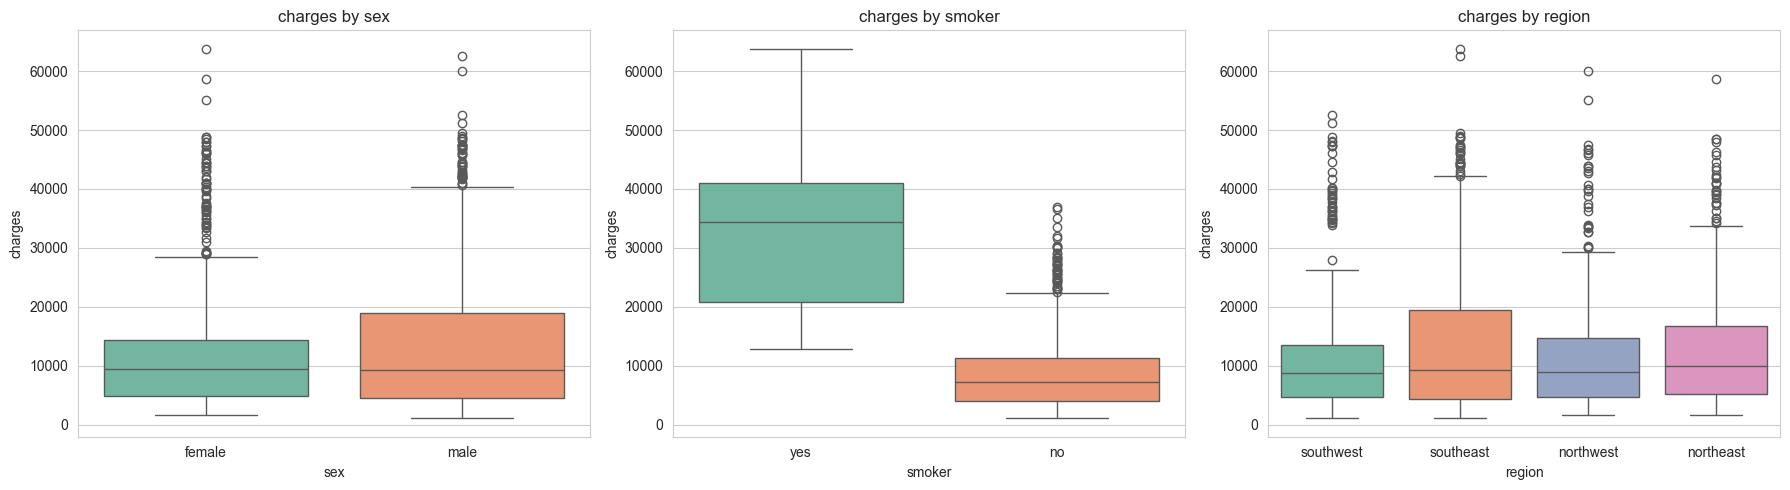

Mean charges by categorical level:

  sex:
           mean  median  count
sex                           
female  12570.0  9413.0    662
male    13957.0  9370.0    676

  smoker:
           mean   median  count
smoker                         
no       8434.0   7345.0   1064
yes     32050.0  34456.0    274

  region:
              mean   median  count
region                            
northeast  13406.0  10058.0    324
northwest  12418.0   8966.0    325
southeast  14735.0   9294.0    364
southwest  12347.0   8799.0    325


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cat_features):
    sns.boxplot(x=col, y="charges", data=df, palette="Set2", ax=axes[i])
    axes[i].set_title(f"charges by {col}")
plt.tight_layout(); plt.show()
print("Mean charges by categorical level:")
for col in cat_features:
    print(f"\n  {col}:")
    print(df.groupby(col)["charges"].agg(["mean","median","count"]).round(0))

## 9. Smoker × BMI Deep-Dive

The single most important interaction in this dataset: smokers with high BMI pay dramatically more.

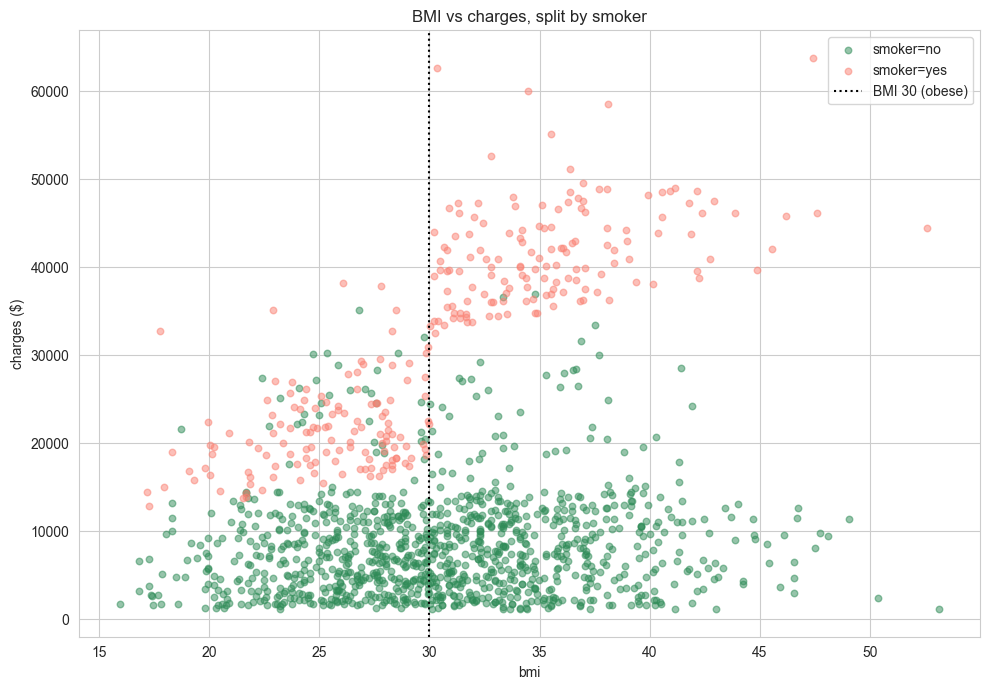

In [11]:
plt.figure(figsize=(10, 7))
for smoker, color in [("no", "seagreen"), ("yes", "salmon")]:
    sub = df[df["smoker"] == smoker]
    plt.scatter(sub["bmi"], sub["charges"], alpha=0.5, color=color, label=f"smoker={smoker}", s=22)
plt.axvline(30, color="black", linestyle=":", label="BMI 30 (obese)")
plt.xlabel("bmi"); plt.ylabel("charges ($)")
plt.title("BMI vs charges, split by smoker")
plt.legend(); plt.tight_layout(); plt.show()

In [12]:
bmi_obese = df["bmi"] >= 30
mean_table = df.groupby([df["smoker"], bmi_obese.map({True:"obese", False:"non-obese"})])["charges"].mean().unstack()
mean_table.columns.name = "BMI"
print("Mean charges by smoker × obese:")
print(mean_table.round(0))

Mean charges by smoker × obese:
BMI     non-obese    obese
smoker                    
no         7977.0   8843.0
yes       21363.0  41558.0


## 10. Correlation Analysis

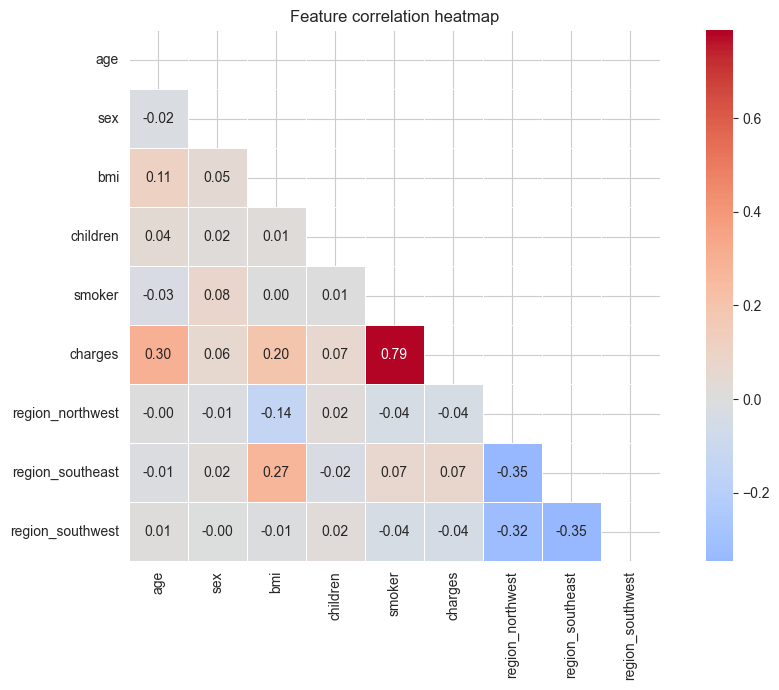

In [13]:
df_corr = df.copy()
df_corr["sex"] = (df_corr["sex"] == "male").astype(int)
df_corr["smoker"] = (df_corr["smoker"] == "yes").astype(int)
df_corr = pd.get_dummies(df_corr, columns=["region"], drop_first=True)
plt.figure(figsize=(10, 7))
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Feature correlation heatmap")
plt.tight_layout(); plt.show()

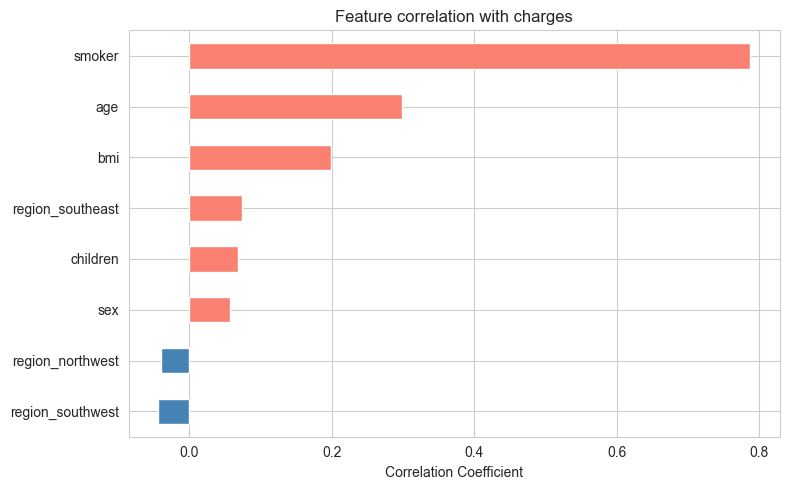

smoker              0.787
age                 0.299
bmi                 0.198
region_southeast    0.074
children            0.068
sex                 0.057
region_northwest   -0.040
region_southwest   -0.043
Name: charges, dtype: float64


In [14]:
target_corr = df_corr.corr()["charges"].drop("charges").sort_values(ascending=False)
plt.figure(figsize=(8, 5))
target_corr.plot(kind="barh",
                 color=["salmon" if x > 0 else "steelblue" for x in target_corr])
plt.title("Feature correlation with charges")
plt.xlabel("Correlation Coefficient")
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()
print(target_corr.round(3))

## 11. Pair Plot — Top Predictors

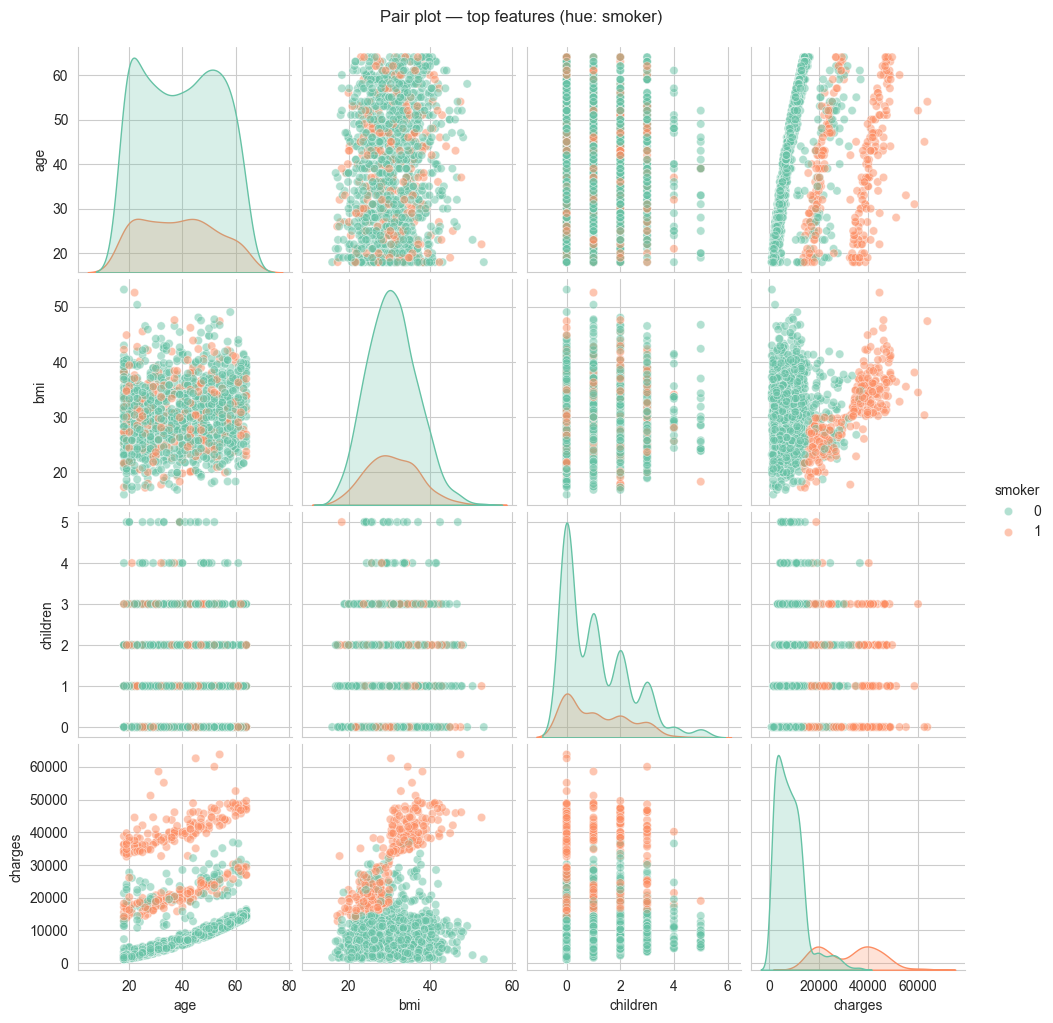

In [15]:
plot_df = df_corr[["age","bmi","smoker","children","charges"]]
sns.pairplot(plot_df, hue="smoker", palette="Set2", diag_kind="kde",
             plot_kws={"alpha": 0.5})
plt.suptitle("Pair plot — top features (hue: smoker)", y=1.02)
plt.show()

## 12. Key EDA Findings

| # | Finding |
|---|--------|
| 1 | **Smoker is the dominant predictor** — smokers pay ~3.8× the mean charges of non-smokers (~$32k vs ~$8.4k) |
| 2 | **BMI compounds the smoker effect**: obese smokers pay ~$41k on average vs ~$21k for non-obese smokers and ~$8k for non-smokers (any BMI) |
| 3 | **Age is the second-strongest signal** (r ≈ 0.30) — charges climb roughly linearly with age |
| 4 | **`charges` is heavily right-skewed** (skewness ≈ 1.5); log-transforming it makes the distribution roughly normal — useful for linear models |
| 5 | **Region effect is weak** (≤ 5–10% mean differences); `sex` is also weak (slight male bias because of higher smoker rates) |
| 6 | **No missing values, no duplicates** — the dataset is clean and ready for modeling |
| 7 | **Three "regimes" of charges** are visually obvious: low (non-smoker), medium (smoker, non-obese), high (smoker, obese). Tree-based models capture this naturally; linear models need the smoker × bmi interaction term |